<a href="https://colab.research.google.com/github/kjmobile/lb2/blob/main/0_colab_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Colab Intro: Get Data with SQL, Then Fit a Line Two Ways

| Part | What you do | Slides (W3.1) |
|---|---|---|
| 1 | Connect to the class database and run SQL from Python | SQL lab |
| 2 | Fit one line two ways: the statistics way and the machine-learning way | 113–120 |

# 0. Connect Database to get the dataset

In [ ]:
! pip install pymysql

In [2]:
# import data from mySQL database  using the following info host: database-klee.cbgcswckszgl.us-east-1.rds.amazonaws.com, id erau, password 1212, db='data', port 3306
import pymysql
import pandas as pd

In [3]:
# 1.1 Practice DB connection
connection = pymysql.connect(
    host='database-klee.cbgcswckszgl.us-east-1.rds.amazonaws.com',
    user='erau',
    password='1212',
    charset='utf8mb4',
    cursorclass=pymysql.cursors.DictCursor
)

cursor = connection.cursor()
print("Connected to database!")

Connected to database!


In [4]:
#1.2 show available databases
cursor.execute("SHOW DATABASES")
print("Available databases:")
for db in cursor.fetchall():
    print(f"- {db['Database']}")

Available databases:
- airline_db
- condo
- hr
- information_schema
- performance_schema
- toy


In [5]:
#1.3 select airline_db by USE commend
cursor.execute("USE airline_db")
print('connected to airline_db')

connected to airline_db


In [6]:
#1.3 airline_db
cursor.execute("SHOW TABLES")
print("\nAvailable tables in airline_db:")
tables = cursor.fetchall()
for table in tables:
    table_name = list(table.values())[0]
    print(f"- {table_name}")


Available tables in airline_db:
- aircraft
- airlines
- airports
- bookings
- flights
- flights_delay
- passengers
- seat_map
- tickets


In [7]:
#1.4 select * from airports table.
cursor.execute("SELECT * FROM airports  WHERE city in ('Paris', 'Tokyo') ")
results =pd.DataFrame(cursor.fetchall())
results

,airport_code,airport_name,city,country,timezone,latitude,longitude
0,CDG,Charles de Gaulle Airport,Paris,France,Europe/Paris,49.00970000,2.54790000
1,HND,Haneda Airport,Tokyo,Japan,Asia/Tokyo,35.54940000,139.77980000
2,NRT,Narita International Airport,Tokyo,Japan,Asia/Tokyo,35.76530000,140.38560000


In [8]:
#1.4 select * from airports table.
cursor.execute("""
SELECT f.flight_number,  a.airline_name
FROM flights f
JOIN airlines a ON f.airline_code = a.airline_code
""")
results =pd.DataFrame(cursor.fetchall())
results

,flight_number,airline_name
0,AA649,American Airlines
1,AA182,American Airlines
2,AA742,American Airlines
3,AA802,American Airlines
4,AA607,American Airlines
...,...,...
210,UA563,United Airlines
211,UA835,United Airlines
212,UA320,United Airlines
213,UA480,United Airlines


In [9]:
cursor.execute('''
SELECT * FROM bookings ORDER BY total_price LIMIT 1
''')
results=pd.DataFrame(cursor.fetchall())
results

,booking_id,passenger_id,booking_date,total_price,currency,payment_status,booking_status
0,BXQTYA,561,2025-07-23 14:52:04,544.81,USD,PAID,CONFIRMED


In [10]:
#1.5 database connection close and cursor close
cursor.close()
connection.close()

---

In [11]:
# 2 Perform compensation database with a single connection
with pymysql.connect(host='database-klee.cbgcswckszgl.us-east-1.rds.amazonaws.com',
                    user='erau',
                    password='1212',
                    db='hr',
                    charset='utf8mb4',
                    cursorclass=pymysql.cursors.DictCursor) as connection:

    with connection.cursor() as cursor:
        # 1. Show available databases
        cursor.execute("SHOW DATABASES")
        print("Available databases:")
        for db in cursor.fetchall():
            print(db['Database'])

        print("\nAvailable tables in selected database:")

        # 2. Show tables in current database
        cursor.execute("SHOW TABLES")
        for table in cursor.fetchall():
            print(list(table.values())[0])

        print("\nFetching compensation:")
        # 3. Fetch Salary_Data and create DataFrame
        cursor.execute("SELECT * FROM compensation")
        df = pd.DataFrame(cursor.fetchall())

# Display the DataFrame
df

Available databases:
airline_db
condo
hr
information_schema
performance_schema
toy

Available tables in selected database:
compensation
flights

Fetching compensation:


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


---
## Part 2. One Line, Two Ways

Question: **how much does a longer flight raise the average fare?**

> **Data.** The notebook reads `sabre_routes_2019.csv` straight from the course GitHub repository. Nothing to upload.
> Each row is one of the 200 busiest U.S. domestic markets in 2019 (both directions combined).
> Source: Sabre Market Intelligence, licensed to Embry-Riddle.

In [12]:
import matplotlib.pyplot as plt

routes = pd.read_csv('https://raw.githubusercontent.com/kjmobile/lb2/main/data/sabre_routes_2019.csv')
routes.head()

,airport_1,airport_2,distance_mi,passengers,avg_fare,lcc_share,hhi,top_airline
0,JFK,LAX,2470.0,3115042.0,349.29,0.321,0.269,DL
1,LGA,ORD,731.0,2600397.0,174.47,0.086,0.293,AA
2,LAX,SFO,337.0,2289910.0,104.55,0.203,0.212,AS
3,LAX,ORD,1741.0,1853120.0,187.84,0.146,0.332,UA
4,LAS,LAX,236.0,1831441.0,73.20,0.438,0.180,WN


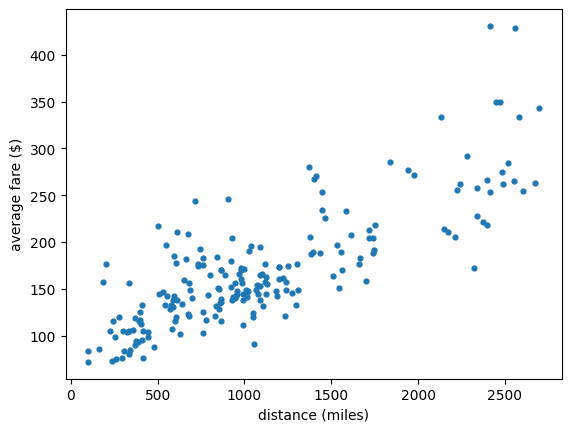

In [13]:
plt.scatter(routes['distance_mi'], routes['avg_fare'], s=12)
plt.xlabel('distance (miles)')
plt.ylabel('average fare ($)')
plt.show()

### 2.1 The statistics way: explain the relationship

Use **all** the data, and ask whether the relationship is real and how big it is.

$$\text{avg\_fare} = \beta_0 + \beta_1 \times \text{distance}$$

In [14]:
import statsmodels.formula.api as smf

ols = smf.ols('avg_fare ~ distance_mi', data=routes).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:               avg_fare   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     375.6
Date:                Fri, 09 Oct 2026   Prob (F-statistic):           1.29e-47
Time:                        10:07:50   Log-Likelihood:                -1006.1
No. Observations:                 200   AIC:                             2016.
Df Residuals:                     198   BIC:                             2023.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      83.4436      5.160     16.171      

**How to read it**
- `distance_mi` coefficient: dollars added per extra mile (about 8 cents).
- `P>|t|` near 0: the relationship is very unlikely to be chance.
- `R-squared`: share of the variation in fares that distance explains.

Report it like this: *Distance significantly predicted average fare, b = 0.079 dollars per mile, p < .001,
R² = 0.655 (200 U.S. markets, 2019).*

### 2.2 The machine-learning way: predict new cases

Hold back 25% of the markets as a **test set**. Fit on the rest, then check how well the line predicts the
markets it has never seen.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = routes[['distance_mi']]
y = routes['avg_fare']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

model = LinearRegression()
model.fit(X_train, y_train)

print('fare =', round(model.intercept_, 1), '+', round(model.coef_[0], 4), 'x distance')

fare = 82.7 + 0.081 x distance


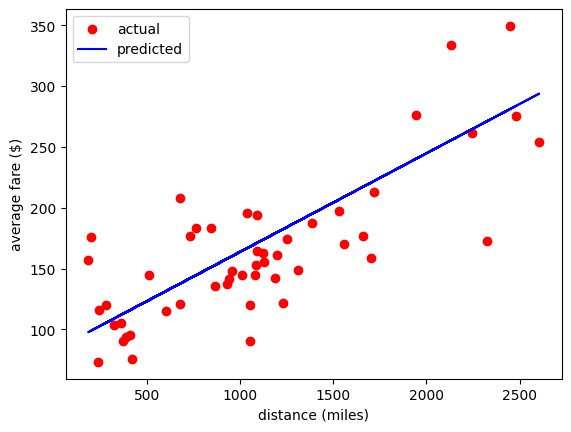

In [16]:
y_pred = model.predict(X_test)

plt.scatter(X_test['distance_mi'], y_test, color='red', label='actual')
plt.plot(X_test['distance_mi'], y_pred, color='blue', label='predicted')
plt.xlabel('distance (miles)')
plt.ylabel('average fare ($)')
plt.legend()
plt.show()

### Your turn

Fit the machine-learning model yourself: create it, fit it on the **training** set, and score it on the **test** set.

Fill in the blanks:

```python
model = ______________()
model.fit(______, ______)
print(model.score(______, ______))
```

<details><summary>Show answer</summary>

```python
model = LinearRegression()
model.fit(X_train, y_train)
print(model.score(X_test, y_test))
```
</details>

In [17]:
# Write your code here

### 2.3 How good are the predictions?

$$R^2 = 1-\frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2}
\qquad
\text{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2
\qquad
\text{RMSE}=\sqrt{\text{MSE}}$$

RMSE is in the same unit as the fare (dollars): the typical size of a miss.

In [18]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
print('Test R2:', round(model.score(X_test, y_test), 3))
print('MSE:    ', round(mse, 1))
print('RMSE:   ', round(np.sqrt(mse), 1), 'dollars')

Test R2: 0.578
MSE:     1481.4
RMSE:    38.5 dollars


| | Statistics way | Machine-learning way |
|---|---|---|
| Goal | Explain: is the relationship real, how big? | Predict: how well on new cases? |
| Data | All of it | Split into train and test |
| Key output | Coefficient, p-value, R² | Test R², RMSE |